In [2]:
# Nguyễn Hoàng Tùng

import pandas as pd

# Path to your CSV file
file_path = r"D:\lecture\PTIT\20251\IntSys\filmReview_1.csv"

# Load dataset
df = pd.read_csv(file_path)

# Show basic info
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

# Check data types & missing values
print("\nInfo:")
print(df.info())

# Basic stats on ratings
print("\nRating distribution:")
print(df['rating'].describe())


Shape: (5000, 7)

Columns: ['review_id', 'user_id', 'user_name', 'film_title', 'rating', 'review_text', 'review_date']

First 5 rows:
   review_id  user_id user_name        film_title  rating  \
0          1      328  user_328         Inception       1   
1          2       72  user_072  Double Indemnity       4   
2          3      217  user_217           Vertigo       1   
3          4      309  user_309  Schindler's List       8   
4          5      230  user_230    Shutter Island       6   

                                         review_text review_date  
0  Not my cup of tea. I struggled to finish it. R...    1/3/2015  
1  Avoidable — wasted potential and boring in pla...   3/31/2023  
2  Disappointing. Expected more based on hype. Re...    5/2/2021  
3  Brilliant — outstanding acting and a memorable...  12/11/2014  
4  It was okay — some parts worked, some didn't. ...   8/29/2025  

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (to

In [7]:
# Nguyễn Hoàng Tùng

import pandas as pd

file_path = r"D:\lecture\PTIT\20251\IntSys\filmReview_1.csv"
df = pd.read_csv(file_path)

reviews = df["review_text"].astype(str).tolist()

from transformers import BertTokenizer, TFBertModel
import tensorflow as tf

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Load BERT (allow loading PyTorch weights into TF model)
bert_model = TFBertModel.from_pretrained("bert-base-uncased", from_pt=True)

# Encode first 5 reviews
inputs = tokenizer(reviews[:5], return_tensors="tf", padding=True, truncation=True, max_length=128)

# Get embeddings
outputs = bert_model(inputs)
last_hidden_states = outputs.last_hidden_state  # shape: (batch_size, seq_len, hidden_size=768)

# Take [CLS] token as sentence embedding
cls_embeddings = last_hidden_states[:, 0, :]  # shape: (batch_size, 768)

print("CLS Embeddings shape:", cls_embeddings.shape)

import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load dataset
file_path = r"D:\lecture\PTIT\20251\IntSys\filmReview_1.csv"
df = pd.read_csv(file_path)

reviews = df["review_text"].astype(str).tolist()

# Tokenize text
vocab_size = 10000   # max number of unique words
max_len = 100        # pad/truncate review length
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(reviews)

sequences = tokenizer.texts_to_sequences(reviews)
padded = pad_sequences(sequences, maxlen=max_len, padding="post", truncating="post")

print("Padded shape:", padded.shape)  # (num_reviews, max_len)

embedding_dim = 100  # size of word vectors

embedding_layer = tf.keras.layers.Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    input_length=max_len
)

# Example: get embeddings for all reviews
embedded_reviews = embedding_layer(padded)  # shape: (num_reviews, max_len, embedding_dim)
print("Embedded reviews shape:", embedded_reviews.shape)

embedding_dim = 100  # size of word vectors

embedding_layer = tf.keras.layers.Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    input_length=max_len
)

# Example: get embeddings for all reviews
embedded_reviews = embedding_layer(padded)  # shape: (num_reviews, max_len, embedding_dim)
print("Embedded reviews shape:", embedded_reviews.shape)

review_vectors = tf.reduce_mean(embedded_reviews, axis=1)  # (num_reviews, embedding_dim)
print("Review vectors shape:", review_vectors.shape)

model = tf.keras.Sequential([
    embedding_layer,
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.LayerNorm.weight', 'cls.predictions.decoder.weight', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already

CLS Embeddings shape: (5, 768)
Padded shape: (5000, 100)
Embedded reviews shape: (5000, 100, 100)
Embedded reviews shape: (5000, 100, 100)
Review vectors shape: (5000, 100)


C:\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [9]:
# Nguyễn Hoàng Tùng

import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import numpy as np

# Load dataset
file_path = r"D:\lecture\PTIT\20251\IntSys\filmReview_1.csv"
df = pd.read_csv(file_path)

# Use review_text and rating
reviews = df["review_text"].astype(str).tolist()
ratings = df["rating"].values

# Optional: convert ratings (1–10) → sentiment (0=bad, 1=good)
labels = (ratings >= 6).astype(int)

# Tokenize
vocab_size = 10000
max_len = 150
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(reviews)

sequences = tokenizer.texts_to_sequences(reviews)
padded = pad_sequences(sequences, maxlen=max_len, padding="post", truncating="post")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(padded, labels, test_size=0.2, random_state=42)

embedding_dim = 100
embedding_layer = tf.keras.layers.Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    input_length=max_len
)

cnn_model = tf.keras.Sequential([
    embedding_layer,
    tf.keras.layers.Conv1D(128, 5, activation="relu"),
    tf.keras.layers.GlobalMaxPooling1D(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

cnn_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
cnn_model.summary()

cnn_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=64)

rnn_model = tf.keras.Sequential([
    embedding_layer,
    tf.keras.layers.SimpleRNN(128),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

rnn_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
rnn_model.summary()

rnn_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=64)

lstm_model = tf.keras.Sequential([
    embedding_layer,
    tf.keras.layers.LSTM(128, return_sequences=False),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

lstm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
lstm_model.summary()

lstm_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=64)

df["predicted_sentiment"] = cnn_model.predict(padded).flatten()
df["predicted_sentiment"] = (df["predicted_sentiment"] >= 0.5).astype(int)

# Film-wise trend (avg sentiment)
film_trends = df.groupby("film_title")["predicted_sentiment"].mean().sort_values(ascending=False)
print(film_trends.head(10))  # top 10 most liked films

user_prefs = df.groupby("user_id")["predicted_sentiment"].mean()
print(user_prefs.head(10))  # example of user preferences

C:\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d                 │ ?                           │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 150, 100)            │       1,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 1,000,000 (3.81 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 154ms/step - accuracy: 0.7445 - loss: 0.5737 - val_accuracy: 0.7650 - val_loss: 0.5583
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.7505 - loss: 0.5642 - val_accuracy: 0.7650 - val_loss: 0.5457
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 158ms/step - accuracy: 0.7505 - loss: 0.5640 - val_accuracy: 0.7650 - val_loss: 0.5525
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 161ms/step - accuracy: 0.7505 - loss: 0.5655 - val_accuracy: 0.7650 - val_loss: 0.5453
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - accuracy: 0.7505 - loss: 0.5638 - val_accuracy: 0.7650 - val_loss: 0.5463
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
film_title
Citizen Kane                                  1.000000
The Lion King                                 1.000000
One Flew Over the Cuckoo's Nest               1.000000
Memories of Murder                            0.968750
Star Wars: Episode VI - Return of the Jedi    0.962963
Donnie Darko                    

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...


Epoch 1/10


[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.9130 - loss: 0.1928 - val_accuracy: 0.9040 - val_loss: 0.2132
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.9130 - loss: 0.1926 - val_accuracy: 0.9040 - val_loss: 0.2131
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9130 - loss: 0.1926 - val_accuracy: 0.9040 - val_loss: 0.2127
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.9130 - loss: 0.1925 - val_accuracy: 0.9040 - val_loss: 0.2130
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.9130 - loss: 0.1926 - val_accuracy: 0.9040 - val_loss: 0.2129
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.9130 - loss: 0.1926 - val_accuracy: 0.9040 - val_loss: 0.2130
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.9130 - loss: 0.1928 - val_accuracy: 0.9040 - val_loss: 0.2131
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9130 - loss: 0.1925 - val_accuracy: 0.9040 - val_loss: 0.

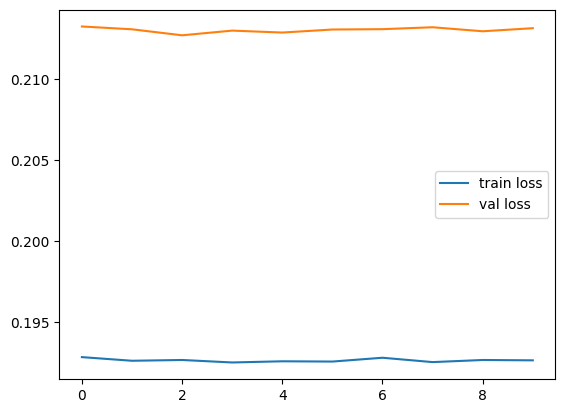

Augmented: ['The motion picture was fantastic and thrilling!']
Epoch 1/10


C:\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.7405 - loss: 1.4473 - val_accuracy: 0.7650 - val_loss: 1.3354 - learning_rate: 1.0000e-04
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.7510 - loss: 1.2616 - val_accuracy: 0.7650 - val_loss: 1.1626 - learning_rate: 1.0000e-04
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.7822 - loss: 1.1044 - val_accuracy: 0.9040 - val_loss: 1.0125 - learning_rate: 1.0000e-04
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9010 - loss: 0.9628 - val_accuracy: 0.9040 - val_loss: 0.8920 - learning_rate: 1.0000e-04
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9128 - loss: 0.8542 - val_accuracy: 0.9040 - val_loss: 0.8049 - learning_rate: 1.0000e-04
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.9130 - loss: 0.7709 - val_accuracy: 0.9040 - val_loss: 0.7373 - learning_rate: 1.0000e-04
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9130 - loss: 0.7

In [13]:
# Nguyễn Hoàng Tùng

import nltk
from nltk.corpus import wordnet

# Download resources if missing
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")
nltk.download("wordnet")
nltk.download("omw-1.4")

history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64
)

import matplotlib.pyplot as plt

def plot_history(history):
    plt.plot(history.history['loss'], label="train loss")
    plt.plot(history.history['val_loss'], label="val loss")
    plt.legend()
    plt.show()

plot_history(history)

from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=1e-4)  # default is 1e-3
cnn_model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

tf.keras.layers.Dropout(0.5)

tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.01))

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

import nlpaug.augmenter.word as naw

# Now it will not crash
aug = naw.SynonymAug(aug_src="wordnet")
text = "The movie was fantastic and thrilling!"
print("Augmented:", aug.augment(text))


cnn_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    tf.keras.layers.Conv1D(128, 5, activation="relu"),
    tf.keras.layers.GlobalMaxPooling1D(),
    tf.keras.layers.Dropout(0.5),   # Dropout
    tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

optimizer = Adam(learning_rate=1e-4)
cnn_model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])

history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop, lr_scheduler]
)
